### L2 model training

Let's train a model using our baseline setup *with L2 regulization*. My network contains 3 hidden layers and 128 hidden units with ReLU activation function. I use the Adam optimiser with a learning rate of 10−4.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import logging
# import sys
# sys.path.append('/path/to/mlpractical')

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer, DropoutLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser
from mlp.train_model_and_plot_stats import train_model_and_plot_stats
from mlp.penalties import L2Penalty

In [2]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng, smooth_labels=False)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng, smooth_labels=False)

KeysView(NpzFile '/Users/hallaei/UoE/mlp/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/Users/hallaei/UoE/mlp/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)


In [3]:
# Setup hyperparameters 
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

error =  CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1: 2.7s to complete
    error(train)=1.34e+00, acc(train)=6.28e-01, error(valid)=1.35e+00, acc(valid)=6.20e-01
Epoch 10: 2.3s to complete
    error(train)=6.59e-01, acc(train)=8.00e-01, error(valid)=6.84e-01, acc(valid)=7.92e-01
Epoch 20: 3.5s to complete
    error(train)=5.23e-01, acc(train)=8.34e-01, error(valid)=5.62e-01, acc(valid)=8.22e-01
Epoch 30: 2.1s to complete
    error(train)=4.67e-01, acc(train)=8.48e-01, error(valid)=5.17e-01, acc(valid)=8.31e-01
Epoch 40: 2.0s to complete
    error(train)=4.32e-01, acc(train)=8.58e-01, error(valid)=4.93e-01, acc(valid)=8.39e-01
Epoch 50: 2.4s to complete
    error(train)=4.11e-01, acc(train)=8.65e-01, error(valid)=4.81e-01, acc(valid)=8.40e-01
Epoch 60: 2.1s to complete
    error(train)=3.95e-01, acc(train)=8.70e-01, error(valid)=4.72e-01, acc(valid)=8.44e-01
Epoch 70: 2.0s to complete
    error(train)=3.84e-01, acc(train)=8.73e-01, error(valid)=4.66e-01, acc(valid)=8.44e-01
Epoch 80: 2.1s to complete
    error(train)=3.70e-01, acc

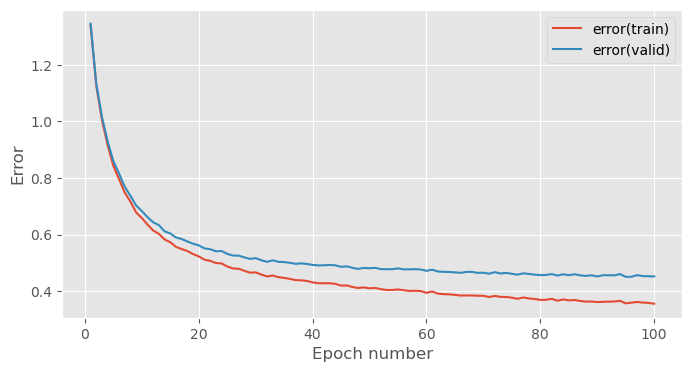

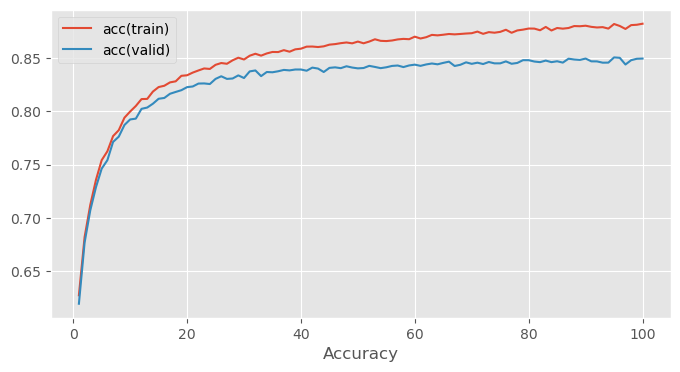

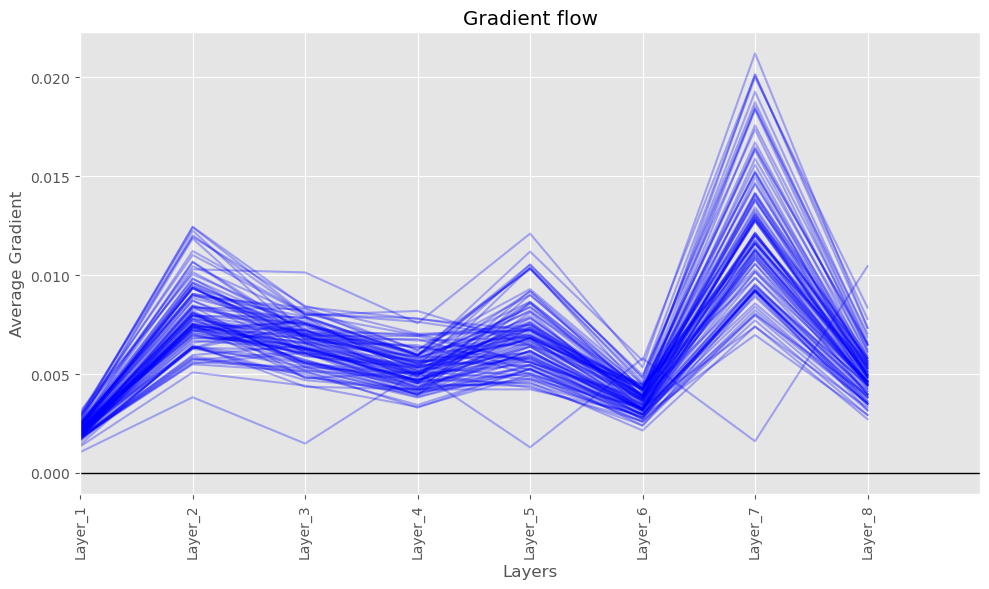

In [4]:
# Create model with three hidden layers and L2 penalties on weights and biases
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=L2Penalty(0.001), biases_penalty=L2Penalty(0.001)), 
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L2Penalty(0.001), biases_penalty=L2Penalty(0.001)),
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L2Penalty(0.001), biases_penalty=L2Penalty(0.001)),
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=L2Penalty(0.001), biases_penalty=L2Penalty(0.001)) # output layer
])

stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)